In [1]:
import tifffile
import os
import math
import time
import multiprocessing
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import multiprocessing
from multiprocessing import get_context

import sys
import time

from stl import mesh
from mpl_toolkits import mplot3d
from IPython.display import clear_output
from skimage import io
from skimage import img_as_ubyte

#### Load Locals ####

import src.mesh_auxillary as ma

### Define Constants     ###
###   representing the   ###
### relative indices of  ###
### directly adjacent    ###
###     NEIGHBORS        ###
# Under no circumstances change these, smartass
# I just got this right by chance - you will loose your mind!

NEIGHBORS = [(2, 1, 1), (0, 1, 1), (1, 2, 1), (1, 0, 1), (1, 1, 2), (1, 1, 0)]

In [3]:
class WalkingCubes:
    
    def __init__(self):
        # Initiate Look Up Table
        self.neighbors = [(2, 1, 1), (0, 1, 1), (1, 2, 1), (1, 0, 1), (1, 1, 2), (1, 1, 0)]
        self.lut = self._generate_lut()

    
    def _generate_lut(self):
    
        lut = {}
        bin = [0,1]
        
        for i in range (2**6):
            binary = f'{i:06b}'
            vec_list = []
            key = np.array([int(bit) for bit in binary])
            
            structure = ma.map_to_3d(key)
            
            for i, n in enumerate(self.neighbors):
                if not structure[n]:
                    vec_list.extend(ma.vert(i))
        
            if len(vec_list) > 0:
                data = np.zeros(len(vec_list), dtype=mesh.Mesh.dtype)
                data['vectors'] = vec_list
                lut[tuple(key)] = data
                
        return lut

    
    def generate_mesh(self, array):

        start_time = time.time()
        it = np.nditer(array[1:, 1:, 1:], flags=['multi_index'])
        mesh_list = []
        
        for x in it:
            
            idx = it.multi_index
            i,j,k = idx
            
            if array[i,j,k]:
                structure = array[i-1:i+2, j-1:j+2, k-1:k+2]
                
                if (bin_map := tuple(ma.map_to_binary(structure))) != (1, 1, 1, 1, 1, 1):
                    msh = self.lut[bin_map].copy()
                    translation = np.array([i + 0.5, j + 0.5, k + 0.5])
                    msh['vectors'] = msh['vectors'] + translation
                    mesh_list.append(msh)
        #print(len(mesh_list), mesh_list)
        data = np.concatenate(mesh_list)
        self.mesh = mesh.Mesh(data, remove_empty_areas = False)
        
        print(f'\n[DEBUG] Finished {len(data)} triangles after {time.time()-start_time} seconds')

In [4]:
walkingcubes = WalkingCubes()

In [9]:
from src.preprocessor import Preprocessor, PreprocessingConfig

array = tifffile.imread('../Data/TS-01/Aligned_predictions_alpha.tif')


## Check if it is in color mode, if so...
if len(array) >= 4 and array.shape[-1] == 3:
    # Collapse color channels
    if np.allclose(array[...,0], array[...,1]) and np.allclose(array[...,0], array[...,2]):
        array = array[...,0]
    else:
        # if channels differ, average or select one
        data = np.mean(array, axis=-1)
    


config = PreprocessingConfig(
cap_size=5,
cap_axis='z', 
padding_size=4,
block_size=128
)

preprocessor = Preprocessor(config)
blocks = preprocessor.blockify(data = array)

In [10]:
padding_size = 2

block = np.pad(blocks[24], ((padding_size, padding_size), (padding_size, padding_size), (padding_size, padding_size)), mode='constant', constant_values=0)

threshold = 127
block = (block > threshold).astype(int)

print(block.shape)

walkingcubes = WalkingCubes()
walkingcubes.generate_mesh(block)
walkingcubes.mesh.save(f'../Data/TS-01/blockx.stl')

(142, 132, 132)

[DEBUG] Finished 379752 triangles after 10.971588611602783 seconds


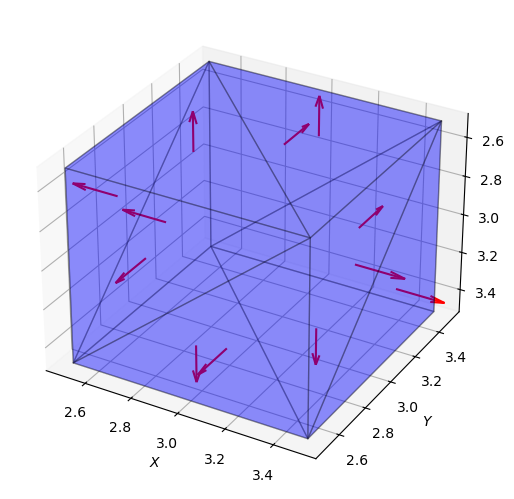

()

In [6]:
ma.show_mesh(walkingcubes.mesh, alpha=0.25, show_normals=True)

In [8]:
data = walkingcubes.mesh

# Recalculate normals
data.update_normals()

# Or alternatively, save with auto-normal calculation
data.save(f'../Data/TS-01/blockx.stl', update_normals=True)



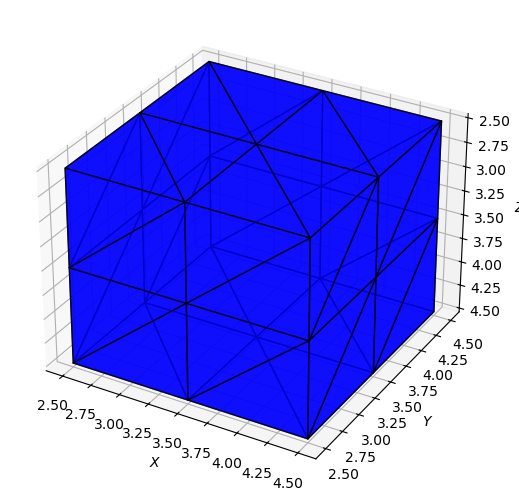

()

In [16]:
ma.show_mesh(data, alpha=.75)

In [3]:
import stl
print(dir(stl))

['BUFFER_SIZE', 'COUNT_SIZE', 'Dimension', 'HEADER_SIZE', 'MAX_COUNT', 'Mesh', 'Mode', 'RemoveDuplicates', '__about__', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'base', 'mesh', 'stl', 'utils']


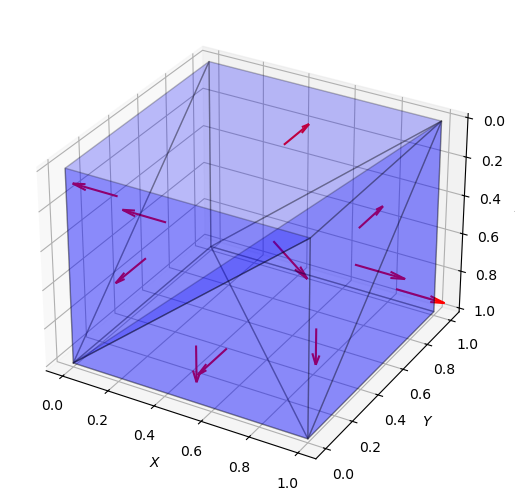

()

In [6]:
protovoxel = ma.create_proto_voxel()

msh = mesh.Mesh(protovoxel, remove_empty_areas=True)
#print(msh.vectors)
#output['normals'][0]=np.array([1,5,1])




ma.show_mesh(msh, show_normals=True)

In [21]:
a = [[0,0,0],[1,0,0],[0,0,1]]
b = [[1,0,0],[0,0,1],[1,0,1]]

print(np.cross(a[1],a[2]))

[ 0 -1  0]


In [24]:


face_normal(np.array(a))

array([ 0., -1.,  0.])

In [8]:
import numpy as np
import tifffile as tiff

# dimensions
Z, Y, X = 256, 256, 256

# allocate volume
vol = np.zeros((X, Y, Z), dtype=np.uint8)
# channel parameters
cy, cx = 128, 128
hy, hx = 10, 10  # half-size -> 20x20

# fill channel across full z
vol[:,cx-10:cx+10, cy-10:cy+10] = 1

# save as multi-page (z-stack) binary TIFF
tiff.imwrite(
    "channel.tif",
    vol*255)